In [3]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el diseño de los gráficos
sns.set_theme(style="whitegrid")

# Cargar los datos desde la carpeta raw (usamos ../ porque el notebook está dentro de la carpeta notebooks)
try:
    df_estudiantes = pd.read_csv('../data/01_raw/estudiantes.csv')
    df_inscripciones = pd.read_csv('../data/01_raw/inscripciones.csv')
    df_calificaciones = pd.read_csv('../data/01_raw/calificaciones.csv')
    df_asistencia = pd.read_csv('../data/01_raw/asistencia.csv')
    
    print("✅ ¡Archivos cargados exitosamente!\n")
    print(f"Estudiantes: {df_estudiantes.shape[0]} filas y {df_estudiantes.shape[1]} columnas")
    print(f"Inscripciones: {df_inscripciones.shape[0]} filas y {df_inscripciones.shape[1]} columnas")
    print(f"Calificaciones: {df_calificaciones.shape[0]} filas y {df_calificaciones.shape[1]} columnas")
    print(f"Asistencia: {df_asistencia.shape[0]} filas y {df_asistencia.shape[1]} columnas")
    
except Exception as e:
    print(f"❌ Error al cargar los archivos: {e}")

✅ ¡Archivos cargados exitosamente!

Estudiantes: 360 filas y 8 columnas
Inscripciones: 927 filas y 8 columnas
Calificaciones: 721 filas y 7 columnas
Asistencia: 618 filas y 5 columnas


In [3]:
# 0. Limpiar la columna 'nota' para asegurarnos de que sea numérica
# Reemplazamos comas por puntos (por si acaso) y forzamos a número (los textos raros quedarán como nulos)
df_calificaciones['nota'] = df_calificaciones['nota'].astype(str).str.replace(',', '.')
df_calificaciones['nota'] = pd.to_numeric(df_calificaciones['nota'], errors='coerce')

# 1. Calcular el promedio de notas por cada inscripción
notas_promedio = df_calificaciones.groupby('id_inscripcion')['nota'].mean().reset_index()
notas_promedio.rename(columns={'nota': 'nota_final'}, inplace=True)

# 2. Calcular el % de asistencia por inscripción
asistencia_total = df_asistencia.groupby('id_inscripcion').size().reset_index(name='total_clases')
ausentes = df_asistencia[df_asistencia['estado_asistencia'].str.lower().isin(['ausente', 'injustificado'])]
asistencia_ausentes = ausentes.groupby('id_inscripcion').size().reset_index(name='clases_ausente')

asistencia_resumen = pd.merge(asistencia_total, asistencia_ausentes, on='id_inscripcion', how='left').fillna(0)
asistencia_resumen['porcentaje_asistencia'] = 100 - ((asistencia_resumen['clases_ausente'] / asistencia_resumen['total_clases']) * 100)

# 3. Construir la Tabla Maestra uniendo (merge) todo
df_master = pd.merge(df_inscripciones, df_estudiantes, on='id_estudiante', how='left')
df_master = pd.merge(df_master, notas_promedio, on='id_inscripcion', how='left')
df_master = pd.merge(df_master, asistencia_resumen[['id_inscripcion', 'porcentaje_asistencia']], on='id_inscripcion', how='left')

# 4. Crear la Variable Objetivo (Target): 1 si Aprueba (nota >= 4.0), 0 si Reprueba
df_master['aprueba'] = np.where(df_master['nota_final'] >= 4.0, 1, 0)

# Ver las primeras 5 filas de nuestra nueva tabla lista para análisis
df_master.head()

,id_inscripcion,id_estudiante,codigo_asignatura,nombre_asignatura,seccion,semestre,año,docente,nombre,rut,carrera,sede,año_ingreso,email,estado_matricula,nota_final,porcentaje_asistencia,aprueba
0,1.0,325.0,ASG-553,Inglés,002D,2.0,2024.0,Agustín Espinoza Vergara,Francisca Pérez Sepúlveda,16998742-1,Psicología,Concepción,2020.0,francisca.pérez@gmail.com,Regular,NaN,100.0,0
1,2.0,70.0,ASG-472,algoritmos,NaN,2.0,2022.0,Tomás Araya Contreras,Paula Bravo Reyes,18674076-0,Arquitectura,NaN,2019.0,paula.bravo@gmail.com,Desertor,5.55,100.0,1
2,3.0,107.0,ASG-930,Algoritmos,001V,1.0,2023.0,Matías Jara Hernández,Benjamín Tapia Soto,9309145-3,Arquitectura,Viña del Mar,2019.0,benjamín.tapia@outlook.com,Regular,1.60,100.0,0
3,4.0,271.0,ASG-983,Programación,001D,2.0,2023.0,Daniela Rojas Castro,Valentina Pérez Reyes,8902729-0,NaN,Santiago Centro,2022.0,NaN,Regular,NaN,NaN,0
4,5.0,NaN,ASG-374,Programación,002D,2.0,NaN,Tomás Muñoz Díaz,Carlos Gatica Medina,NaN,Administración,Santiago Centro,2023.0,carlos.gatica@outlook.com,REGULAR,4.40,NaN,1


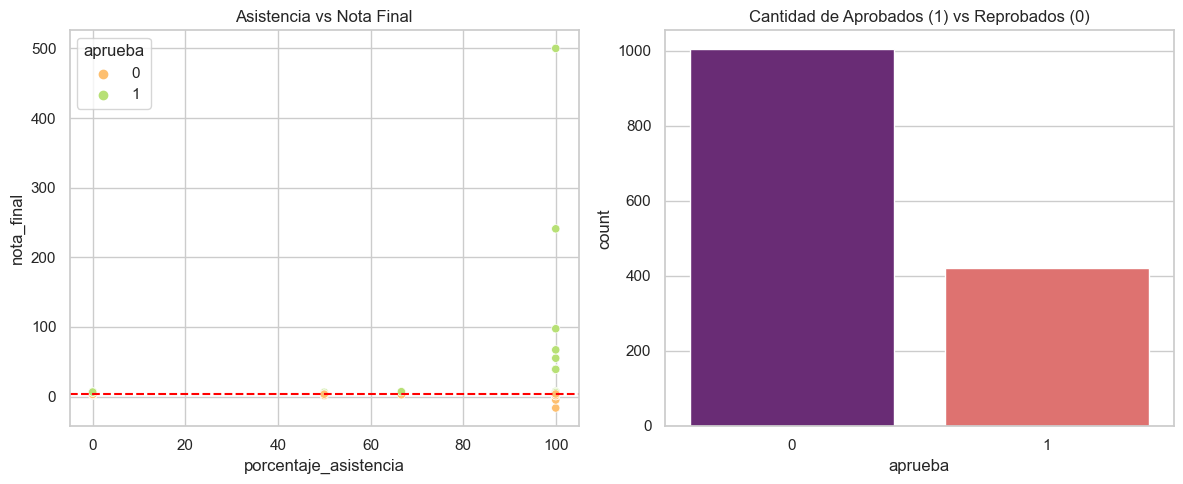

✅ Tabla maestra creada y gráficos generados.


In [4]:
# --- 1. LIMPIEZA Y PREPARACIÓN ---
# Aseguramos que las notas sean números
df_calificaciones['nota'] = pd.to_numeric(df_calificaciones['nota'].astype(str).str.replace(',', '.'), errors='coerce')

# Calculamos el promedio por alumno/inscripción
notas_promedio = df_calificaciones.groupby('id_inscripcion')['nota'].mean().reset_index()
notas_promedio.rename(columns={'nota': 'nota_final'}, inplace=True)

# Calculamos % de asistencia
asistencia_total = df_asistencia.groupby('id_inscripcion').size().reset_index(name='total')
ausentes = df_asistencia[df_asistencia['estado_asistencia'].str.lower().str.contains('ausente|injustificado', na=False)]
asistencia_ausentes = ausentes.groupby('id_inscripcion').size().reset_index(name='faltas')

asistencia_resumen = pd.merge(asistencia_total, asistencia_ausentes, on='id_inscripcion', how='left').fillna(0)
asistencia_resumen['porcentaje_asistencia'] = 100 - ((asistencia_resumen['faltas'] / asistencia_resumen['total']) * 100)

# Unimos todo en la Tabla Maestra
df_master = pd.merge(df_inscripciones, df_estudiantes, on='id_estudiante', how='left')
df_master = pd.merge(df_master, notas_promedio, on='id_inscripcion', how='left')
df_master = pd.merge(df_master, asistencia_resumen[['id_inscripcion', 'porcentaje_asistencia']], on='id_inscripcion', how='left')

# Definimos variable objetivo: 1 es Aprueba (>= 4.0), 0 es Reprueba
df_master['aprueba'] = np.where(df_master['nota_final'] >= 4.0, 1, 0)

# --- 2. VISUALIZACIÓN (EDA) ---
plt.figure(figsize=(12, 5))

# Gráfico de Dispersión: Asistencia vs Nota
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_master, x='porcentaje_asistencia', y='nota_final', hue='aprueba', palette='RdYlGn')
plt.title('Asistencia vs Nota Final')
plt.axhline(4.0, color='red', linestyle='--')

# Gráfico de Barras: Conteo de Aprobados
plt.subplot(1, 2, 2)
sns.countplot(data=df_master, x='aprueba', palette='magma')
plt.title('Cantidad de Aprobados (1) vs Reprobados (0)')

plt.tight_layout()
plt.show()

print("✅ Tabla maestra creada y gráficos generados.")

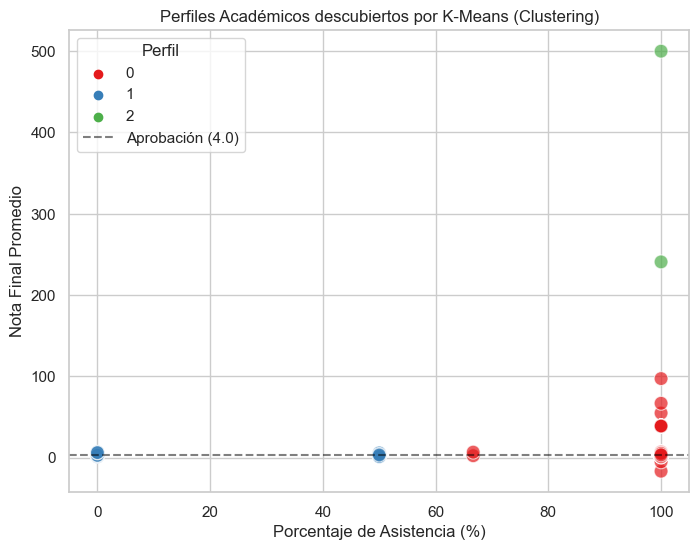

✅ Clustering completado. Observa cómo el algoritmo agrupó a los estudiantes.


In [5]:
# --- 3. APRENDIZAJE NO SUPERVISADO (CLUSTERING K-MEANS) ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparar los datos: Seleccionamos solo Asistencia y Nota Final
# K-Means no acepta valores nulos, así que filtramos las filas incompletas
df_cluster = df_master[['porcentaje_asistencia', 'nota_final']].dropna().copy()

# 2. Escalar los datos: Es obligatorio en K-Means para que ambas variables pesen lo mismo
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_cluster)

# 3. Aplicar K-Means (Vamos a buscar 3 grupos o "perfiles" de estudiantes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['perfil_academico'] = kmeans.fit_predict(datos_escalados)

# 4. Visualizar los perfiles encontrados
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_cluster, 
    x='porcentaje_asistencia', 
    y='nota_final', 
    hue='perfil_academico', 
    palette='Set1', 
    s=100, 
    alpha=0.7
)

plt.title('Perfiles Académicos descubiertos por K-Means (Clustering)')
plt.xlabel('Porcentaje de Asistencia (%)')
plt.ylabel('Nota Final Promedio')
plt.axhline(4.0, color='black', linestyle='--', alpha=0.5, label='Aprobación (4.0)')
plt.legend(title='Perfil')
plt.show()

print("✅ Clustering completado. Observa cómo el algoritmo agrupó a los estudiantes.")